<a href="https://colab.research.google.com/github/JavierCarrillo12/Computacion-visual-jtorresle-jugomezra-dagarzonmo-jacarrillo/blob/main/Talleres/2025_07_18_taller_slam_visual_simulado_opencv/python/2025_07_18_taller_slam_visual_simulado_opencv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install opencv-python numpy matplotlib --quiet

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Task 1


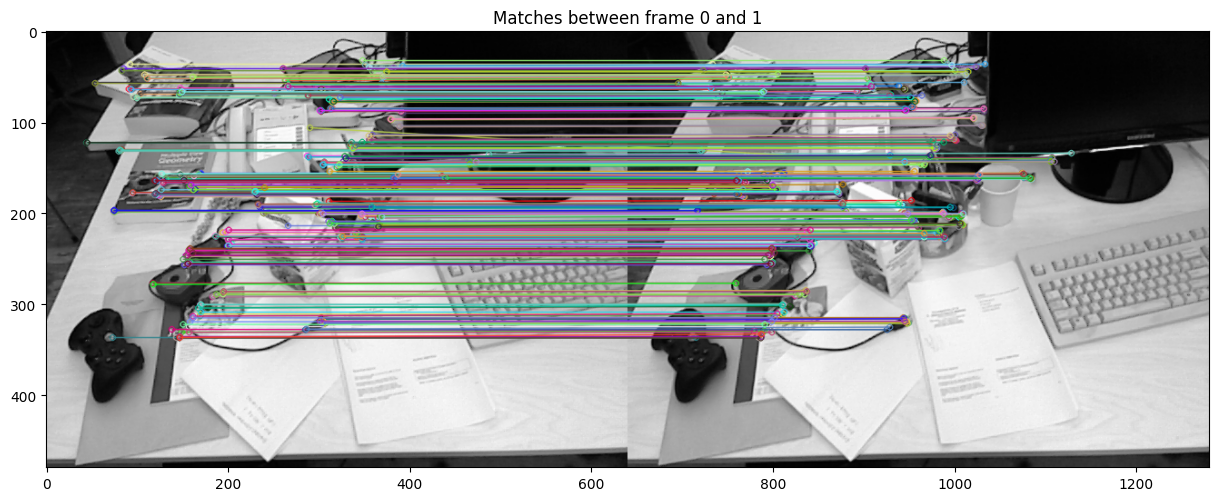

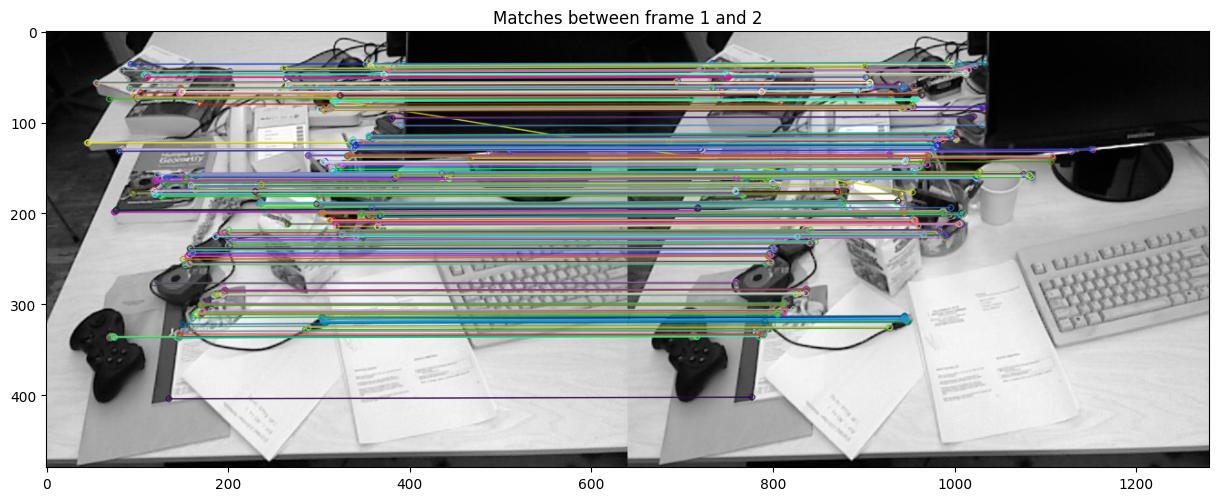

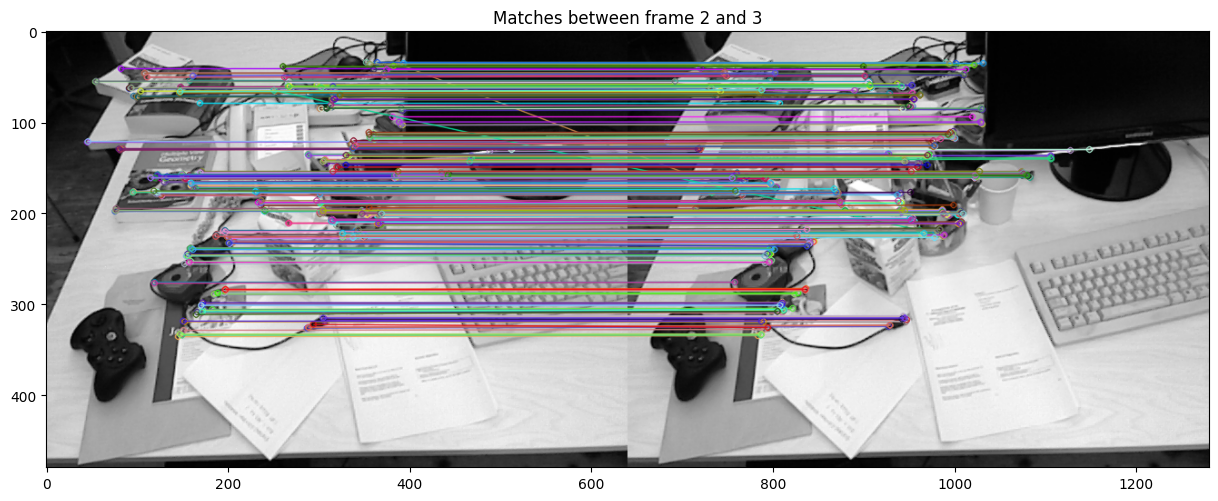

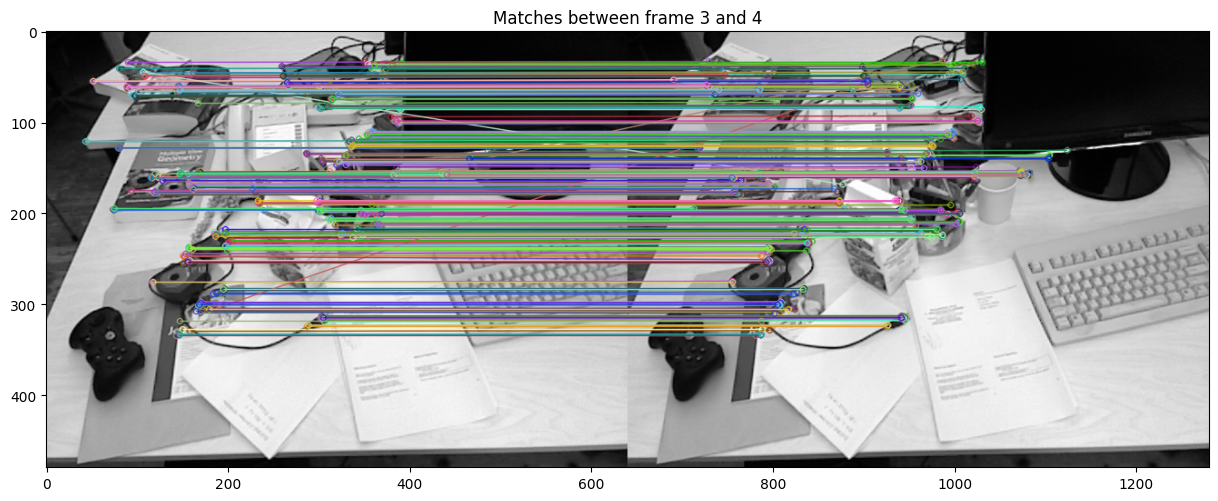

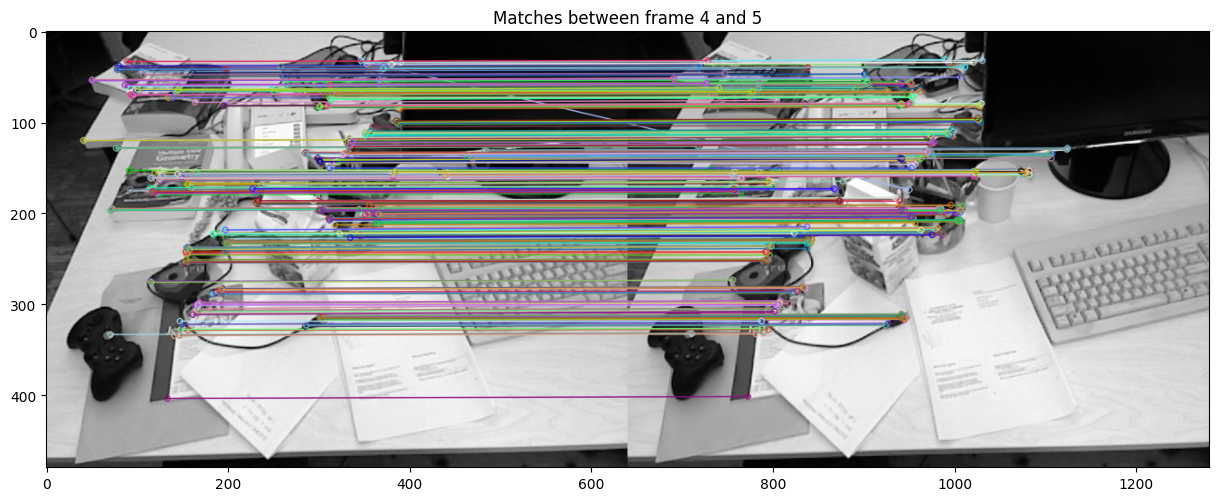

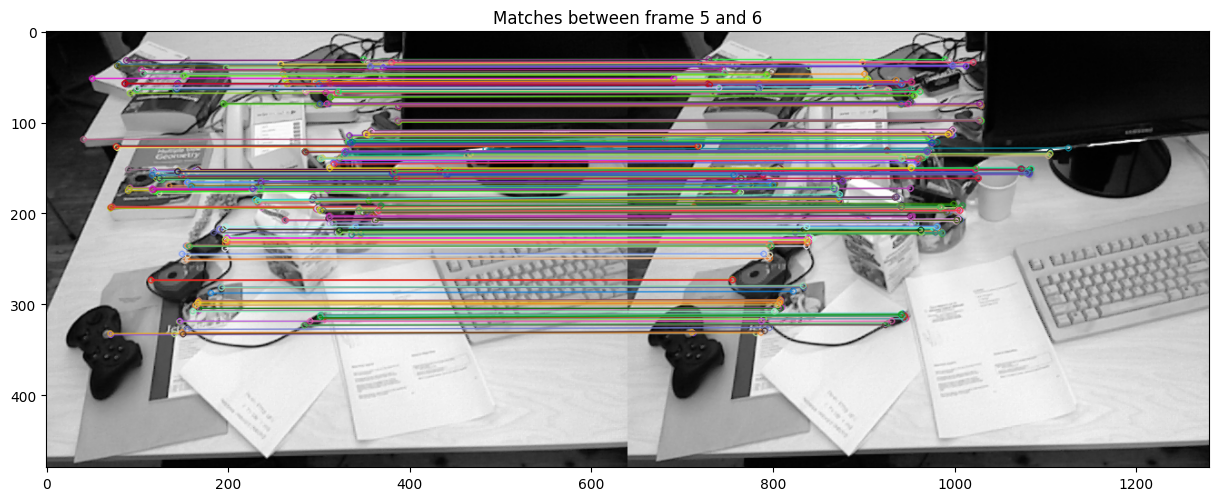

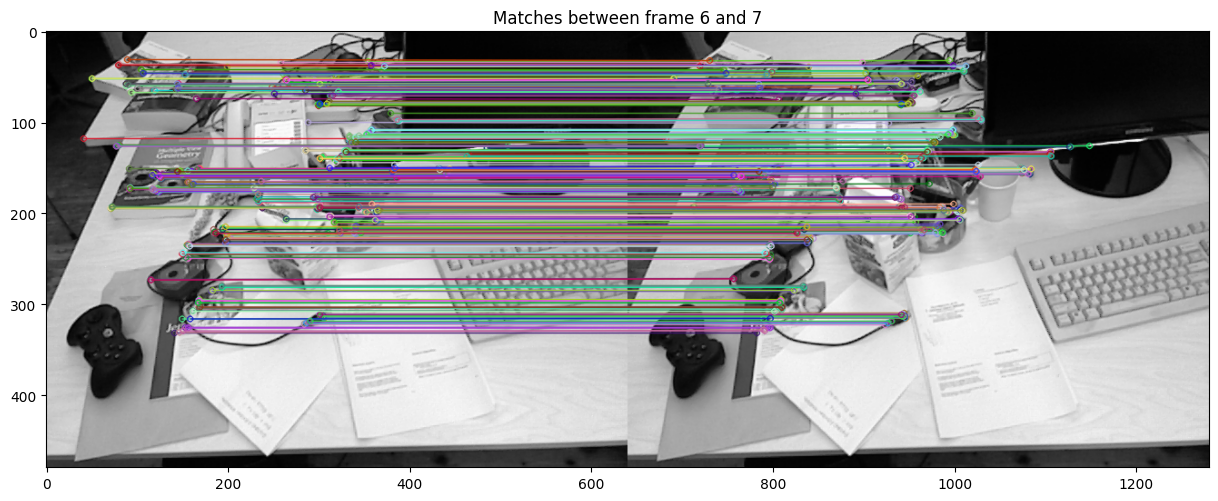

Finished processing 8 frames.
Total detected keypoints: 3500
Total matched point pairs across consecutive frames: 2715


In [ ]:
# This cell adapts the logic from the "Task 1" cells to track points across selected frames

# Initialize ORB and BFMatcher outside the loop
orb = cv2.ORB_create()
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# List to store all detected keypoints for potential visualization
all_detected_keypoints = []
# List to store matching points between consecutive frames
all_matched_points1 = []
all_matched_points2 = []

prev_frame = None

# Iterate through the selected frames
for i, (t, fname) in enumerate(selected):
    curr_frame = cv2.imread(fname, cv2.IMREAD_GRAYSCALE) # Load as grayscale

    if curr_frame is None:
        print(f"Warning: Could not load frame {fname}. Skipping.")
        continue

    # If it's not the first frame, perform feature detection and matching
    if prev_frame is not None:
        # Feature detection and computation (similar to cell 7UqgbOVFMH2R)
        kp1, des1 = orb.detectAndCompute(prev_frame, None)
        kp2, des2 = orb.detectAndCompute(curr_frame, None)

        # Store all detected keypoints from the current frame
        if kp2 is not None:
            all_detected_keypoints.extend([p.pt for p in kp2])

        # Matching (similar to cell gVcPFW0UMJ2g)
        if des1 is not None and des2 is not None:
            matches = bf.match(des1, des2)

            # Extract matching points (similar to cell aCWk7MaWMLz5)
            if matches: # Check if there are any matches
                pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
                pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

                # Store the matched points
                all_matched_points1.extend(pts1)
                all_matched_points2.extend(pts2)

                # You could optionally add code here to visualize the matches for the current frame pair
                img_matches = cv2.drawMatches(prev_frame, kp1, curr_frame, kp2, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
                plt.figure(figsize=(15, 10))
                plt.imshow(img_matches)
                plt.title(f"Matches between frame {i-1} and {i}")
                plt.show()

    # Set the current frame as the previous frame for the next iteration
    prev_frame = curr_frame

print(f"Finished processing {len(selected)} frames.")
print(f"Total detected keypoints: {len(all_detected_keypoints)}")
print(f"Total matched point pairs across consecutive frames: {len(all_matched_points1)}")

# Now you can use all_detected_keypoints, all_matched_points1, and all_matched_points2
# for further analysis or visualization, e.g., plotting all detected keypoints

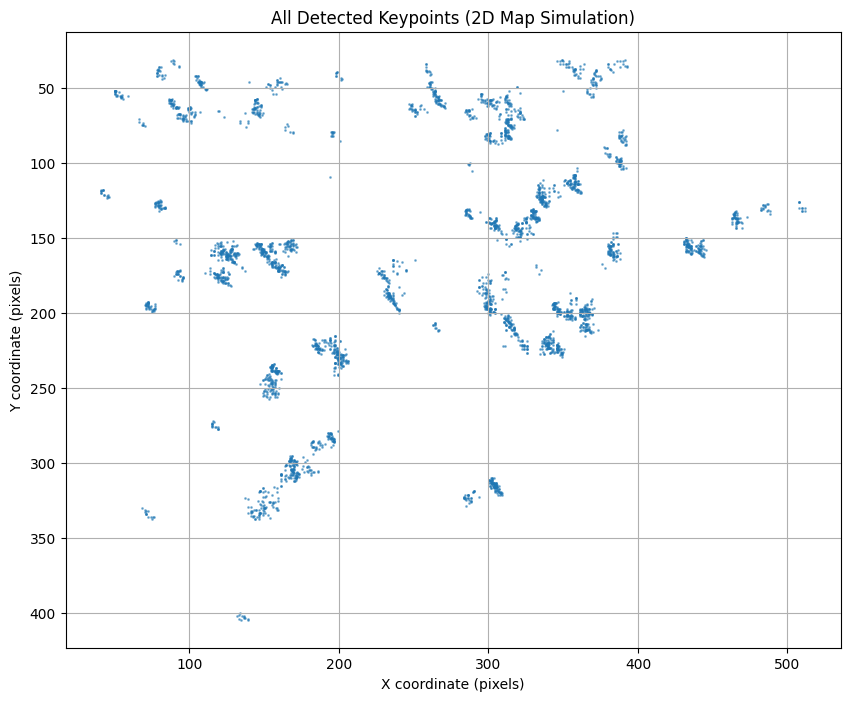

In [ ]:
# Convert the list of all_detected_keypoints to a NumPy array for easier plotting
all_detected_keypoints_np = np.array(all_detected_keypoints)

# Check if there are any keypoints to plot
if all_detected_keypoints_np.size > 0:
    # Plot all detected keypoints as a scatter plot
    plt.figure(figsize=(10, 8))
    plt.scatter(all_detected_keypoints_np[:, 0], all_detected_keypoints_np[:, 1], s=1, alpha=0.5)
    plt.xlabel("X coordinate (pixels)")
    plt.ylabel("Y coordinate (pixels)")
    plt.title("All Detected Keypoints (2D Map Simulation)")
    plt.gca().invert_yaxis() # Invert the Y-axis to match image coordinates
    plt.grid(True)
    plt.show()
else:
    print("No keypoints were detected across the frames to plot.")